In [1]:
import numpy as np
import glob, os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
import pandas as pd

In [17]:
data_path = r'G:\My Drive\Researches\Projects\Solid plasma\code\dataset\Cu alloy'
file_pattern = os.path.join(data_path, "*.csv") 
all_files = sorted(glob.glob(file_pattern))

# Initialize six lists for the three sets
x_train, y_train = [], []
x_val, y_val     = [], []
x_test, y_test   = [], []

for filename in all_files:
    data = np.loadtxt(filename, delimiter=',')
    all_spectra = data.T  

    label = os.path.basename(filename).split('.')[0]
    x_train.extend(all_spectra[:70])
    y_train.extend([label] * 70)
    
    x_val.extend(all_spectra[70:85])
    y_val.extend([label] * 15)

    x_test.extend(all_spectra[85:])
    y_test.extend([label] * 15)

x_train, y_train = np.array(x_train), np.array(y_train)
x_val, y_val     = np.array(x_val),   np.array(y_val)
x_test, y_test   = np.array(x_test),  np.array(y_test)

print(f"Training set:   {x_train.shape}, {y_train.shape}")
print(f"Validation set: {x_val.shape}, {y_val.shape}")
print(f"Testing set:    {x_test.shape}, {y_test.shape}")

Training set:   (420, 2048), (420,)
Validation set: (90, 2048), (90,)
Testing set:    (90, 2048), (90,)


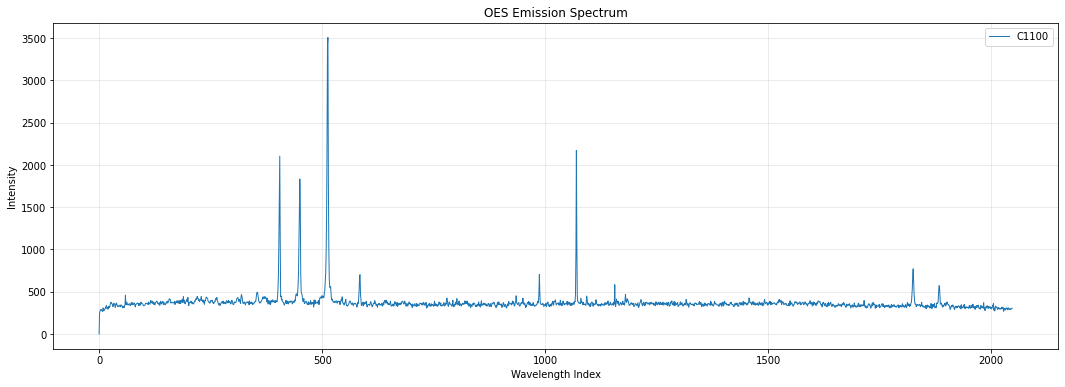

In [18]:
plt.figure(figsize=(18, 6))
plt.plot(x_train[0,:], label=y_train[0], linewidth=1)

plt.title('OES Emission Spectrum')
plt.xlabel('Wavelength Index')
plt.ylabel('Intensity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

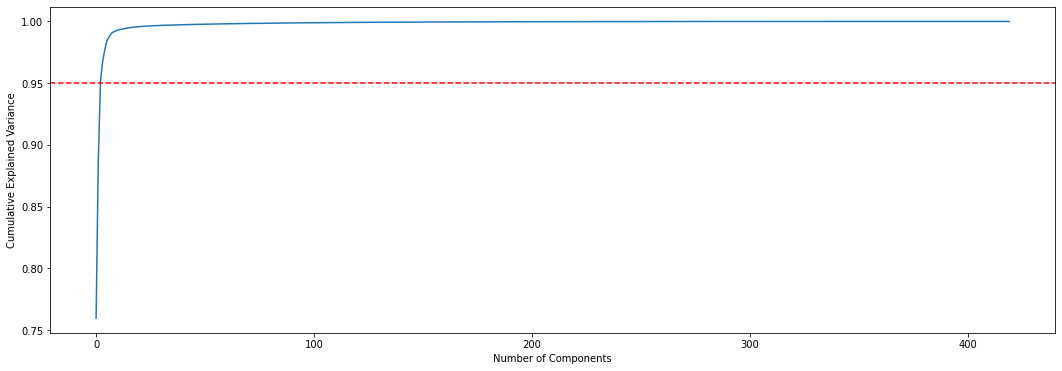

In [19]:
pca = PCA() 
pca_features = pca.fit_transform(x_train)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(18, 6))
plt.plot(explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.show()

np.savetxt('pca_features.csv', explained_variance, delimiter=',', fmt='%.3f')

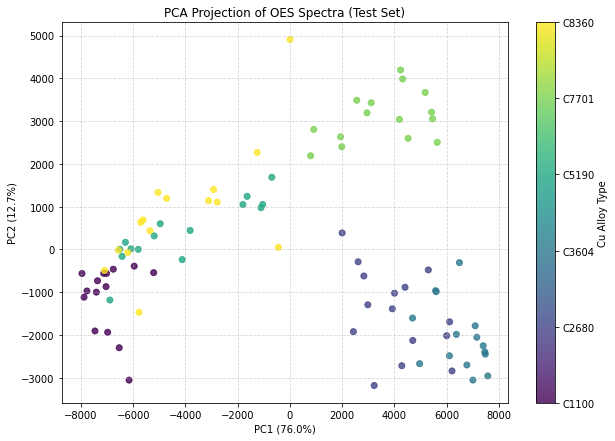

In [25]:
# 1. PCA Logic
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train) # Learn from training
x_test_pca = pca.transform(x_test)       # Apply to testing

# 2. Map Alloy Names to Numbers for Coloring
unique_alloys = np.unique(y_test)
label_map = {name: i for i, name in enumerate(unique_alloys)}
numerical_labels = np.array([label_map[name] for name in y_test])

# 3. Plotting
plt.figure(figsize=(10, 7))

# We plot all 90 test points at once. 
# 'c' takes the 90 numerical labels to assign colors automatically.
scatter = plt.scatter(x_test_pca[:, 0], x_test_pca[:, 1], 
                      c=numerical_labels, 
                      cmap='viridis', 
                      alpha=0.8)

# Add colorbar and fix the ticks to show alloy names
cbar = plt.colorbar(scatter)
cbar.set_ticks(np.arange(len(unique_alloys)))
cbar.set_ticklabels(unique_alloys)
cbar.set_label('Cu Alloy Type')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Projection of OES Spectra (Test Set)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [33]:
pca = PCA(n_components=3)
pca_3d = pca.fit_transform(x_train)
pca_3d = pca.transform(x_test_scaled)

print(f"Total Variance Explained by 3 PCs: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Total Variance Explained by 3 PCs: 95.13%


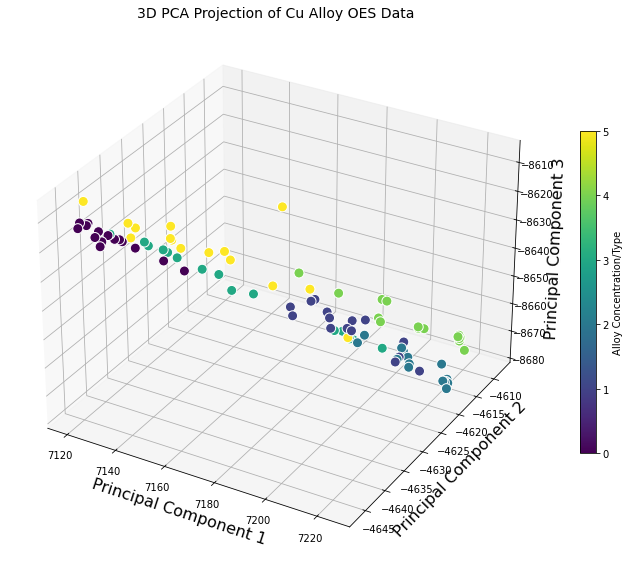

PermissionError: [Errno 13] Permission denied: 'pca_3d.csv'

In [34]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(pca_3d[:, 0], pca_3d[:, 1], pca_3d[:, 2], c=numerical_labels, cmap='viridis', s=100,  alpha=1, edgecolors='w')    
ax.set_xlabel('Principal Component 1', fontsize=16)
ax.set_ylabel('Principal Component 2', fontsize=16)
ax.set_zlabel('Principal Component 3', fontsize=16)
ax.set_title('3D PCA Projection of Cu Alloy OES Data', fontsize=14)
plt.colorbar(sc, ax=ax, label='Alloy Concentration/Type', shrink=0.6)

plt.tight_layout()
plt.show()

np.savetxt('pca_3d.csv', pca_3d, delimiter=',', fmt='%.2f')
np.savetxt('numerical_labels.csv', numerical_labels, delimiter=',', fmt='%.0f')

In [8]:
x_test_scaled = scaler.transform(x_test)
x_test_pca = pca.transform(x_test_scaled)
print(f"Test data shape after PCA: {x_test_pca.shape}")

Test data shape after PCA: (90, 3)


In [9]:
train_pca = pca.transform(x_train_scaled) 
test_pca  = pca.transform(x_test_scaled) 

pca_knn = KNeighborsClassifier(n_neighbors=3)
pca_knn.fit(train_pca, y_train) 

y_pred = pca_knn.predict(test_pca)

print(f"Accuracy using PCA features: {accuracy_score(y_test, y_pred)*100:.2f}%")

Accuracy using PCA features: 94.44%


In [10]:
knn_model = KNeighborsClassifier(n_neighbors=30)
knn_model.fit(x_train, y_train) 

y_pred = knn_model.predict(x_test)

print(f"Accuracy using KNeighborsClassifier features: {accuracy_score(y_test, y_pred)*100:.2f}%")

Accuracy using KNeighborsClassifier features: 96.67%


In [29]:
svm_model = SVC(kernel='rbf', C=0.35, gamma='scale')
svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)

print(f"Accuracy using KNeighborsClassifier features: {accuracy_score(y_test, y_pred_svm)*100:.2f}%")

Accuracy using KNeighborsClassifier features: 94.44%


In [12]:
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)
print(f"Accuracy using KNeighborsClassifier features: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

Accuracy using KNeighborsClassifier features: 96.67%


In [26]:
log_model = LogisticRegression(max_iter=10)
log_model.fit(x_train, y_train)

y_pred_log = log_model.predict(x_test)
print(f"Accuracy using KNeighborsClassifier features: {accuracy_score(y_test, y_pred_log)*100:.2f}%")

Accuracy using KNeighborsClassifier features: 95.56%


C:\Users\Nguyen H D Khang\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
model_list = [
    ("KNN", knn_model), 
    ("SVM", svm_model), 
    ("Random Forest", rf_model),
    ("LogisticRegression", log_model)
]

comparison_data = []

for name, model in model_list:
    # Get predictions
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    comparison_data.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# Create a clean DataFrame
df_compare = pd.DataFrame(comparison_data)
print(df_compare)

                Model  Accuracy  Precision  Recall  F1-Score
0                 KNN    0.9667     0.9700  0.9667    0.9666
1                 SVM    0.9444     0.9500  0.9444    0.9441
2       Random Forest    0.9667     0.9700  0.9667    0.9670
3  LogisticRegression    0.9556     0.9596  0.9556    0.9554


In [15]:
model_list = [
    ("PCA", pca_knn)
]

comparison_data = []

for name, model in model_list:
    # Get predictions
    y_pred = model.predict(x_test_pca)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    comparison_data.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

# Create a clean DataFrame
df_compare = pd.DataFrame(comparison_data)
print(df_compare)

  Model  Accuracy  Precision  Recall  F1-Score
0   PCA    0.9444     0.9465  0.9444    0.9448


In [31]:
print("Detailed Report for Random Forest:")
print(classification_report(y_test, rf_model.predict(x_test)))

Detailed Report for Random Forest:
              precision    recall  f1-score   support

       C1100       1.00      1.00      1.00        15
       C2680       0.88      1.00      0.94        15
       C3604       1.00      0.93      0.97        15
       C5190       0.94      1.00      0.97        15
       C7701       1.00      0.93      0.97        15
       C8360       1.00      0.93      0.97        15

    accuracy                           0.97        90
   macro avg       0.97      0.97      0.97        90
weighted avg       0.97      0.97      0.97        90



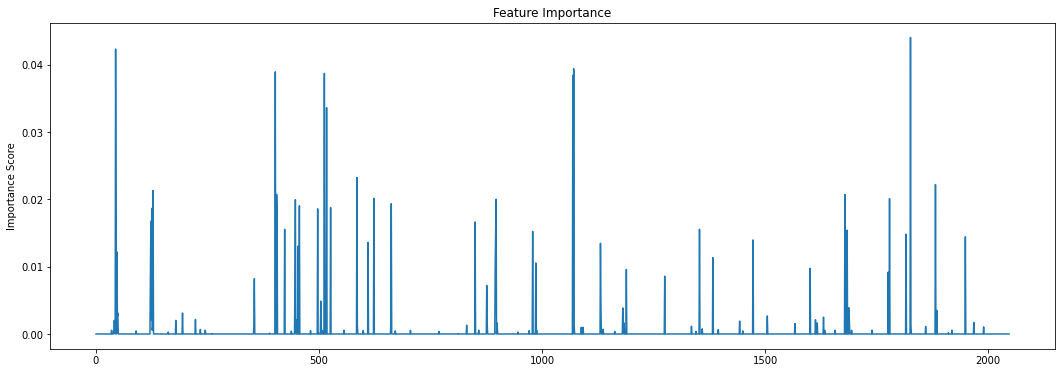

In [32]:
importances = rf_model.feature_importances_

plt.figure(figsize=(18, 6))
plt.plot(importances)
plt.ylabel('Importance Score')
plt.title('Feature Importance')
plt.show()

np.savetxt('importances.csv', importances, delimiter=',', fmt='%.5f')

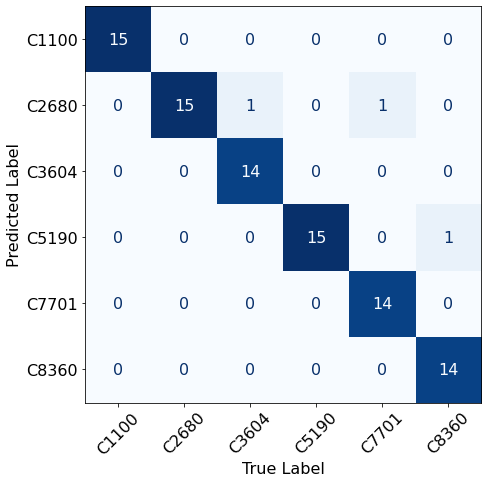

In [33]:
plt.rcParams.update({'font.size': 16}) 
y_pred = rf_model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
cm_flipped = cm.T 

unique_labels = np.unique(y_test)

fig, ax = plt.subplots(figsize=(7, 7))
cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_flipped, 
    display_labels=unique_labels
)

cmd.plot(cmap='Blues', ax=ax, colorbar=False)

ax.set_xlabel('True Label')
ax.set_ylabel('Predicted Label')

plt.xticks(rotation=45)

plt.tight_layout() 
plt.show()

np.savetxt('cm_flipped.csv', cm_flipped, delimiter=',', fmt='%.0f')